# HVSR analysis 

In [8]:
from pathlib import Path
from dataclasses import asdict
import hashlib
import importlib.metadata
import platform
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next((folder for folder in (WORKING_DIR, *WORKING_DIR.parents)
             if (folder / 'utils/hvsr_tools.py').is_file() and (folder / 'data').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Run from the repository root or main/01_processing.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv
from utils import plotting as hp

versions = {name: importlib.metadata.version(name) for name in ('hvsrpy', 'obspy', 'numpy', 'scipy', 'pandas', 'matplotlib')}
versions['python'] = platform.python_version()

## 1. Inputs
 

In [9]:
INPUT_FILES = {component: ROOT / f'data/sac/00P2-2_WA.WAU40..HH{component}.D.2020.281.sac' for component in 'NEZ'}
STARTTIME = None
ENDTIME = None
SAVE_OUTPUTS = True
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_PREFIX = '00P2-2'
SHOW_WINDOW_CURVES = True
FIGURE_STYLE = hp.PaperStyle(width_in=6.4, font_size=7.0, tick_size=6.0, legend_size=6.0, dpi=300)
FIGURE_FORMATS = ('pdf', 'svg', 'png')

record = hv.load_record(INPUT_FILES, starttime=STARTTIME, endtime=ENDTIME)
display(pd.Series(record.meta, name='Recording'))

file name(s)                   [/home/orincon/ciudad-perdida-hvsr/data/sac/00...
deployed degrees from north                                                  0.0
current degrees from north                                                   0.0
station                                                                   00P2-2
starttime                                            2020-10-07T08:18:39.000000Z
sampling_rate_hz                                                           100.0
duration_s                                                              28160.99
Name: Recording, dtype: object

## Window selection and processing


In [10]:
params = hv.HVSRParams(
    # 1. Window duration and placement
    window_length_s=200.0,
    overlap_pct=0.0,
    window_selection='continuous',

    # 2. Time-domain screening of raw recordings
    anti_trigger=True,
    sta_s=2.0,
    lta_s=30.0,
    sta_lta_min=0.2,
    sta_lta_max=2.0,
    sta_lta_method='vector',
    sta_lta_amplitude='abs',
    transient_padding_s=2.0,
    max_crest_factor=6.0,
    clip_threshold_pct=None,

    # 3. Waveform preprocessing and FFT
    filter_corners_hz=(None, None),
    filter_order=5,
    detrend='constant',
    orient_to_degrees_from_north=None,
    taper_pct_per_side=5.0,
    fft_zero_padding=False,

    # 4. Spectral smoothing and horizontal combination
    smoothing='konno_and_ohmachi',
    smoothing_bandwidth=40.0,
    horizontal_combination='squared_average',

    # 5. Frequency sampling and peak-search band
    fmin=0.2,
    fmax=45.0,
    n_frequencies=800,
    frequency_spacing='log',
    peak_range_hz=None,

    # 6. Optional rejection based on H/V curves
    frequency_domain_rejection=False,
    fdr_n=2.5,
)
result = hv.run_hvsr(record, params)
display(pd.Series(result.summary(), name='Analysis summary'))
fourier_data = hv.component_fourier_data(record, result)
component_spectra = fourier_data.smoothed

67/140 windows | f0=10.06025 Hz | A0=5.09334


n_grid_windows               140.000000
n_windows_time_selection      67.000000
n_candidates_before_crest    123.000000
n_crest_rejected              56.000000
n_windows                     67.000000
retained_fraction              0.478571
f0_mean_curve_hz              10.060252
A0_mean_curve                  5.093340
f0_windows_hz                  8.832008
f0_windows_low_hz              7.010468
f0_windows_high_hz            11.126841
f0_windows_std_hz              2.266002
A0_windows                     5.621285
fdr_iterations                      NaN
runtime_s                      0.203000
Name: Analysis summary, dtype: float64

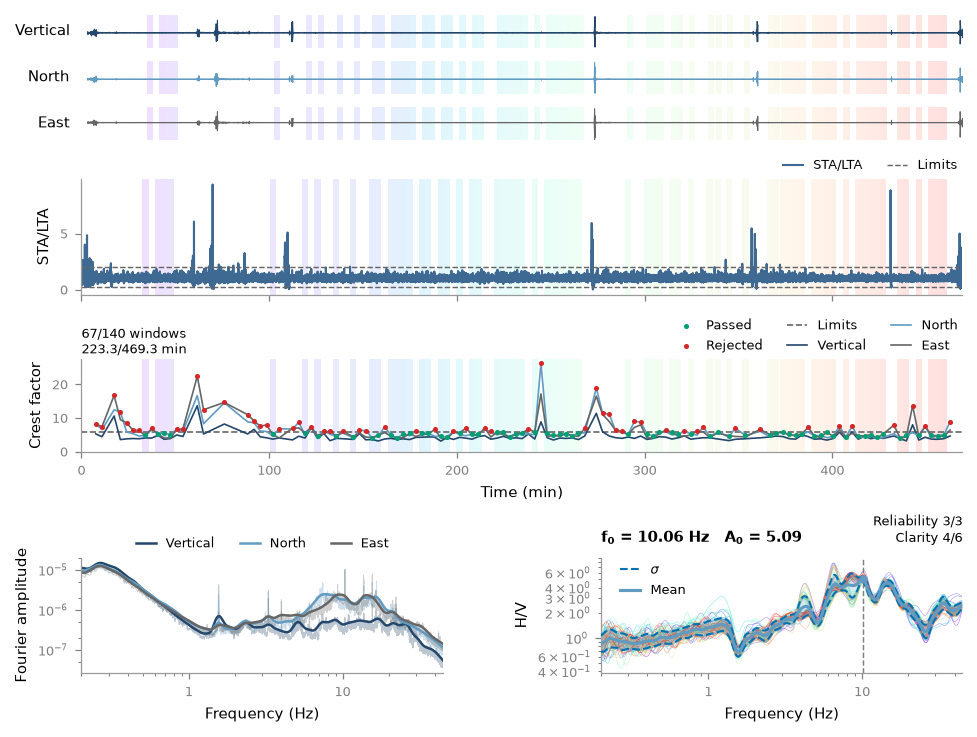

In [11]:
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

FIGURE_CONTROLS = {
    'height_in': 4.8,
    'show_raw_signals': True,
    'raw_height_ratio': 1.2,
    'height_ratios': (1.0, 1.0),
    'crest_height_ratio': 0.8,
    'crest_component_alpha': 1.0,
    'component_colors': {'Z': '#24476B', 'N': '#619BC2', 'E': '#666666'},
    'component_linestyles': {'Z': '-', 'N': '-', 'E': '-'},
    'line_width': 0.8,
    'fourier_line_width': 1.2,
    'fourier_grid': False,
    'window_cmap': 'rainbow',
    'accepted_alpha': 0.12,
    'sta_lta_ylim': None,
    'sta_lta_components': ('E',),
    'sta_lta_vector_color': '#3e6993ff',
    'sta_lta_line_width': 1.0,
    'sta_lta_alpha': 1.0,
    'fourier_yscale': 'log',
    'show_unsmoothed_fourier': True,
    'unsmoothed_fourier_alpha': 0.3,
    'unsmoothed_fourier_line_width': 0.5,
    'hvsr_yscale': None,
    'hvsr_window_alpha': 0.5,
    'hvsr_title_font_size': 7.0,
    'grid': False,
    'hspace': 0.04,  # Vertical spacing between rows
    'wspace': 0.15,  # Horizontal spacing between columns
}

def make_analysis_figure(record, result, component_spectra, controls, style, show_windows=False,
                         fourier_data=None):
    if controls['show_unsmoothed_fourier'] and fourier_data is None:
        raise ValueError('Rerun the processing cell to calculate unsmoothed Fourier amplitudes.')
    labels = {'Z': 'Vertical', 'N': 'North', 'E': 'East'}
    attributes = {'Z': 'vt', 'N': 'ns', 'E': 'ew'}
    if not controls['sta_lta_components'] or not set(controls['sta_lta_components']) <= set(labels):
        raise ValueError('sta_lta_components must contain N, E and/or Z.')
    dt = record.vt.dt_in_seconds
    time = np.arange(record.vt.n_samples) * dt / 60
    with hp.paper_context(style):
        figure = plt.figure(figsize=(style.width_in, controls['height_in']), layout='constrained')
        figure.get_layout_engine().set(
            hspace=controls['hspace'],
            wspace=controls['wspace'],
        )
        show_crest = result.params.max_crest_factor is not None
        ratios = list(controls['height_ratios'])
        if show_crest:
            ratios.insert(1, controls['crest_height_ratio'])
        raw_offset = int(controls['show_raw_signals'])
        if raw_offset:
            ratios.insert(0, controls['raw_height_ratio'])
        grid = figure.add_gridspec(len(ratios), 2, height_ratios=ratios)
        sta_lta_ax = figure.add_subplot(grid[raw_offset, :])
        crest_ax = figure.add_subplot(grid[raw_offset + 1, :], sharex=sta_lta_ax) if show_crest else None
        fourier_ax = figure.add_subplot(grid[-1, 0])
        hvsr_ax = figure.add_subplot(grid[-1, 1], sharex=fourier_ax)
        raw_axes = []
        if raw_offset:
            raw_grid = grid[0, :].subgridspec(3, 1, hspace=0.02)
            for index, (component, attribute) in enumerate(attributes.items()):
                axis = figure.add_subplot(raw_grid[index, 0], sharex=sta_lta_ax)
                signal = getattr(record, attribute)
                times, lower, upper = hp.waveform_envelope(signal.amplitude, dt)
                axis.fill_between(times, lower, upper, color=controls['component_colors'][component],
                                  edgecolor=controls['component_colors'][component],
                                  linewidth=0.5, rasterized=True, zorder=1)
                axis.set_ylabel(labels[component], rotation=0, ha='right', va='center',
                                labelpad=8, fontweight='normal')
                hp.style_axes(axis, style=style)
                axis.set_yticks([])
                axis.spines['left'].set_visible(False)
                axis.spines['bottom'].set_visible(False)
                axis.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
                raw_axes.append(axis)

        starts = result.window_starts_s[result.valid_mask] / 60
        ranks = np.argsort(np.argsort(starts))
        window_colors = plt.get_cmap(controls['window_cmap'])(ranks / max(len(starts) - 1, 1))
        length = result.params.window_length_s / 60
        polygons = [[(start, 0), (start + length, 0), (start + length, 1), (start, 1)]
                    for start in starts]
        time_axes = raw_axes + [sta_lta_ax] + ([crest_ax] if show_crest else [])
        for time_axis in time_axes:
            time_axis.add_collection(PolyCollection(
                polygons, transform=time_axis.get_xaxis_transform(),
                facecolors=window_colors, alpha=controls['accepted_alpha'],
                edgecolors='none', zorder=0))
        if show_crest:
            hp.plot_crest_factor(result, ax=crest_ax, style=style,
                                 component_alpha=controls['crest_component_alpha'],
                                 component_colors=controls['component_colors'])
            crest_ax.set_title('')
            crest_ax.legend(loc='lower right', bbox_to_anchor=(1, 1.02),
                            ncols=3, borderaxespad=0, fontsize=style.legend_size)
            sta_lta_ax.tick_params(labelbottom=False)
        displayed = ('R',) if result.params.sta_lta_method == 'vector' else controls['sta_lta_components']
        for component in displayed:
            label = 'STA/LTA' if component == 'R' else labels[component]
            ratio = result.diagnostics['sta_lta'].get(component)
            if ratio is None:
                if component == 'R':
                    ratio = hv.vector_sta_lta_ratio(record, result.params.sta_s, result.params.lta_s,
                                                   result.params.sta_lta_amplitude)
                else:
                    ratio = hv.sta_lta_ratio(getattr(record, attributes[component]).amplitude, dt,
                                            result.params.sta_s, result.params.lta_s,
                                            result.params.sta_lta_amplitude)
            finite = np.flatnonzero(np.isfinite(ratio))
            if not finite.size:
                warnings.warn(f'{label} STA/LTA has no finite values.', RuntimeWarning)
                continue
            color = controls['sta_lta_vector_color'] if component == 'R' else controls['component_colors'][component]
            sta_lta_ax.plot(time, ratio, color=color,
                            linestyle='-' if component == 'R' else controls['component_linestyles'][component],
                            lw=controls['sta_lta_line_width'], alpha=controls['sta_lta_alpha'],
                            label=label, rasterized=True)
        # Show thresholds even when anti-trigger is disabled; in that case they are diagnostic only.
        for index, limit in enumerate((result.params.sta_lta_min, result.params.sta_lta_max)):
            sta_lta_ax.axhline(limit, color='0.4', ls='--', lw=0.7,
                              label='Limits' if index == 0 else None)
        sta_lta_ax.set(xlim=(0, (record.vt.n_samples - 1) * dt / 60),
                       xlabel='Time (min)', ylabel='STA/LTA')
        if show_crest:
            sta_lta_ax.set_xlabel('')
        if controls['sta_lta_ylim'] is not None:
            sta_lta_ax.set_ylim(controls['sta_lta_ylim'])
        handles, legend_labels = sta_lta_ax.get_legend_handles_labels()
        sta_lta_ax.legend(handles, legend_labels, ncols=3, loc='lower right',
                          bbox_to_anchor=(1, 1.02), borderaxespad=0)
        included_samples = 0
        covered_end = 0
        for start in np.sort(np.rint(result.window_starts_s[result.valid_mask] / dt).astype(int)):
            end = min(start + result.diagnostics['n_win'], record.vt.n_samples)
            included_samples += max(0, end - max(start, covered_end))
            covered_end = max(covered_end, end)
        included_min = included_samples * dt / 60
        total_min = (record.vt.n_samples - 1) * dt / 60
        selection_annotation = (
            f'{result.n_windows}/{result.n_grid_windows} windows\n'
            f'{included_min:.1f}/{total_min:.1f} min')
        annotation_ax = crest_ax if show_crest else sta_lta_ax
        annotation_ax.text(0, 1.02, selection_annotation, transform=annotation_ax.transAxes,
                        ha='left', va='bottom', fontsize=style.legend_size)

        for component, label in labels.items():
            if controls['show_unsmoothed_fourier']:
                visible = ((fourier_data.raw_frequency >= result.params.fmin)
                           & (fourier_data.raw_frequency <= result.params.fmax))
                raw = fourier_data.raw[component][:, visible]
                log_raw = np.full_like(raw, -np.inf)
                np.log(raw, out=log_raw, where=raw > 0)
                raw_mean = np.exp(log_raw.mean(axis=0))
                fourier_ax.plot(fourier_data.raw_frequency[visible], raw_mean,
                                color=controls['component_colors'][component],
                                alpha=controls['unsmoothed_fourier_alpha'],
                                lw=controls['unsmoothed_fourier_line_width'], zorder=1,
                                label='_nolegend_', rasterized=True)
            mean = np.exp(np.log(component_spectra[component]).mean(axis=0))
            fourier_ax.plot(result.frequency, mean, label=label,
                            color=controls['component_colors'][component],
                            linestyle=controls['component_linestyles'][component],
                            lw=controls['fourier_line_width'], zorder=2)
        fourier_ax.set(xscale='log', yscale=controls['fourier_yscale'],
                       xlim=(result.params.fmin, result.params.fmax), xlabel='Frequency (Hz)',
                       ylabel='Fourier amplitude')
        fourier_ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
        fourier_ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02),
                          ncols=3, borderaxespad=0)
        hp.plot_hvsr(result, show_windows=show_windows, title='', ax=hvsr_ax,
                     yscale=controls['hvsr_yscale'],
                     window_alpha=controls['hvsr_window_alpha'],
                     window_cmap=controls['window_cmap'], style=style)
        peak_annotation = hvsr_ax.texts[0]
        peak_title = peak_annotation.get_text().replace('\n', '   ')
        peak_annotation.remove()
        hvsr_ax.set_title(peak_title, loc='center', y=1.1, pad=0,
                          fontweight='bold', math_fontfamily='dejavusans')
        hvsr_ax.title.set_text(peak_title.replace('$f_0$', r'$\mathbf{f_0}$')
                               .replace('$A_0$', r'$\mathbf{A_0}$'))
        hvsr_ax.title.set_x(0)
        hvsr_ax.title.set_horizontalalignment('left')
        hvsr_ax.title.set_verticalalignment('bottom')
        legend_handles, legend_labels = hvsr_ax.get_legend_handles_labels()
        legend_order = [legend_labels.index(label) for label in (r'$\sigma$', 'Mean')
                        if label in legend_labels]
        hvsr_ax.legend([legend_handles[index] for index in legend_order],
                       [legend_labels[index] for index in legend_order],
                       loc='upper left', bbox_to_anchor=(0.04, 1),
                       ncols=1, borderaxespad=0, fontsize=style.legend_size, frameon=False)
        sesame_metrics = hv.assess_sesame_quality(result, time_blocks=None)['metrics']
        sesame_label = (
            f"Reliability {sesame_metrics['reliability_count']}/3\n"
            f"Clarity {sesame_metrics['clarity_count']}/6")
        hvsr_ax.text(1, 1.1, sesame_label, transform=hvsr_ax.transAxes,
                     ha='right', va='bottom', fontsize=style.legend_size,
                     fontweight='normal')
        for axis in (sta_lta_ax, fourier_ax, hvsr_ax):
            hp.style_axes(axis, grid=controls['grid'], style=style)
        if controls['fourier_yscale'] == 'log':
            fourier_ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1,)))
            fourier_ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 5)))
            fourier_ax.yaxis.set_minor_formatter(NullFormatter())
        if controls['fourier_grid']:
            fourier_ax.grid(which='major', color='0.92', linewidth=0.4)
        hvsr_ax.title.set_fontsize(controls['hvsr_title_font_size'])
        return figure

analysis_figure = make_analysis_figure(record, result, component_spectra, FIGURE_CONTROLS,
                                       FIGURE_STYLE, show_windows=SHOW_WINDOW_CURVES,
                                       fourier_data=fourier_data)
plt.show()

## 3. SESAME report


In [14]:
quality = hv.assess_sesame_quality(result, time_blocks=None)
display(pd.DataFrame(quality['criteria']))
print(f"Reliability: {quality['metrics']['reliability_count']}/3; clarity: {quality['metrics']['clarity_count']}/6")


,criterion,description,value,comparison,threshold,passed
0,R1,Cycles per window,2012.050303,>,10.00,True
1,R2,Total cycles,134807.370288,>,200.00,True
2,R3,"Maximum amplitude scatter in [f0/2, 2*f0]",1.393153,<,2.00,True
3,C1,Minimum amplitude below peak / A0,0.238516,<,0.50,True
4,C2,Minimum amplitude above peak / A0,0.235912,<,0.50,True
5,C3,Peak amplitude,5.093340,>,2.00,True
6,C4,Maximum relative shift of +/-1 sigma peaks,0.150142,<,0.05,False
7,C5,Window-peak standard deviation / f0,0.225243,<,0.05,False
8,C6,Amplitude scatter at f0,1.072286,<,1.58,True


Reliability: 3/3; clarity: 4/6


## 4. Export


In [13]:
if SAVE_OUTPUTS:
    def input_hash(path):
        digest = hashlib.sha256()
        with path.open('rb') as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b''):
                digest.update(chunk)
        return digest.hexdigest()
    paths = [Path(path) for path in record.meta['file name(s)']]
    metadata = {
        'quality': quality, 'versions': versions,
        'figure_style': asdict(FIGURE_STYLE), 'figure_formats': FIGURE_FORMATS,
        'figure_controls': FIGURE_CONTROLS,
        'input_sha256': {str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path): input_hash(path) for path in paths},
        'requested_interval_utc': {'starttime': STARTTIME, 'endtime': ENDTIME},
    }
    exported = hv.save_outputs(result, OUTPUT_DIR, OUTPUT_PREFIX, extra=metadata)
    figure_exports = {
        'analysis': hp.save_figure(analysis_figure, OUTPUT_DIR / f'{OUTPUT_PREFIX}_analysis', formats=FIGURE_FORMATS, style=FIGURE_STYLE),
    }
    print('Saved to', OUTPUT_DIR)
    display(exported)
else:
    print('Output saving disabled.')

Saved to /home/orincon/ciudad-perdida-hvsr/outputs


{'curve': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_curve.csv'),
 'windows': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_windows.csv'),
 'summary': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_summary.json'),
 'selection': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_selection.csv')}